# 🧬 Discovering Emerging Topics in Drug Discovery Research using BERTopic

In [1]:
!pip -q install bertopic umap-learn hdbscan sentence-transformers transformers accelerate wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.0 MB/s eta 0:00:00


In [3]:
!pip install biopython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.6 MB/s eta 0:00:00


## 1️⃣Import dependencies

In [1]:
# Only run this full os part to prevent hard crashes by limiting CPU threads
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
import re, spacy
import pandas as pd
import nbformat
import IPython
import json
import matplotlib.pyplot as plt
import random
import numpy as np
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

from wordcloud import WordCloud
from Bio import Entrez, Medline
from bertopic import BERTopic
from transformers import pipeline
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## 2️⃣ Data Collection
I used PubMed  to fetch abstracts on topics like 'drug discovery', 'AI drug design', and 'molecular docking'.
Store as `data/raw_publications.csv`.

In [ ]:
Entrez.email = "paulafredrick26@gmail.com"  # already set
# 1. Search PubMed
handle = Entrez.esearch(
    db="pubmed",
    term=query,
    retmax=max_results,
    sort="relevance"
)
search_results = Entrez.read(handle)
handle.close()

pmids = search_results["IdList"]
print("Number of PMIDs found:", len(pmids))

# 2. Fetch details
handle = Entrez.efetch(
    db="pubmed",
    id=",".join(pmids),
    rettype="medline",
    retmode="text"
)
records = list(Medline.parse(handle))
handle.close()

# 3. Build DataFrame
rows = []
for rec in records:
    abstract = rec.get("AB", "")
    if not abstract:
        continue
    rows.append({
        "pmid": rec.get("PMID", ""),
        "title": rec.get("TI", ""),
        "abstract": abstract,
        "journal": rec.get("JT", ""),
        "year": rec.get("DP", "")[:4]
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

# 4. Save CSV
os.makedirs("data", exist_ok=True)
df.to_csv("data/raw_publications.csv", index=False)
print("Saved to data/raw_publications.csv")

Number of PMIDs found: 1000
(976, 5)
Saved to data/raw_publications.csv


## 3️⃣ Data Cleaning & Preprocessing

In [ ]:
nlp = spacy.load("en_core_web_sm")

def clean_text(text):
    text = str(text)
    # collapse whitespace
    text = re.sub(r"\s+", " ", text)
    # remove punctuation, make lowercase
    text = re.sub(r"[^\w\s]", "", text.lower())
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and token.is_alpha
    ]
    return " ".join(tokens)

In [5]:
df = pd.read_csv("raw_publications.csv")
df["clean_text"] = df["abstract"].apply(clean_text)
df.head()

NameError: name 'clean_text' is not defined

In [ ]:
df.to_csv("data/raw_publications.csv", index=False)

In [6]:
df["clean_text"].isna().sum(), df["clean_text"].head()

(np.int64(0),
 0    molecular docking establish silico structureba...
 1    pharmaceutical research successfully incorpora...
 2    molecular docking essential structural biologi...
 3    artificial intelligence ai present new industr...
 4    molecular docking important component drug dis...
 Name: clean_text, dtype: object)

## 4️⃣ Embedding Generation

In [ ]:
import torch
torch.manual_seed(SEED)
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    df['clean_text'],
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

In [ ]:
# Saving the embeddings
np.save("data/embeddings.npy", embeddings)

In [7]:
# Load the embeddings
embeddings = np.load("embeddings.npy")
print("df rows:", len(df))
print("emb rows:", embeddings.shape[0])

df rows: 976
emb rows: 976


## 5️⃣ Topic Modelling with BERTopic

In [8]:
umap_model = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=12, metric='euclidean', cluster_selection_method='eom', prediction_data=False)

topic_model = BERTopic(umap_model=umap_model, hdbscan_model=hdbscan_model, calculate_probabilities=False,   # keeps memory lower
    verbose=True)
topics, _ = topic_model.fit_transform(df["clean_text"], embeddings)
topic_model.get_topic_info().head(15)

2026-01-19 10:33:07,428 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-19 10:33:15,963 - BERTopic - Dimensionality - Completed ✓
2026-01-19 10:33:15,965 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-19 10:33:15,992 - BERTopic - Cluster - Completed ✓
2026-01-19 10:33:16,005 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-19 10:33:16,107 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,256,-1_compound_inhibitor_drug_study,"[compound, inhibitor, drug, study, molecular, ...",[background delta play key role bcell signal t...
1,0,260,0_docking_ligand_protein_bind,"[docking, ligand, protein, bind, drug, screeni...",[computational docking means prioritise small ...
2,1,108,1_drug_discovery_method_design,"[drug, discovery, method, design, model, molec...",[drug designing development important area res...
3,2,106,2_virus_drug_protease_antiviral,"[virus, drug, protease, antiviral, viral, comp...",[emergence new variant raise concern effective...
4,3,47,3_kinase_inhibitor_compound_cell,"[kinase, inhibitor, compound, cell, cancer, ta...",[kinase key target approximately breast cancer...
5,4,44,4_ad_disease_compound_inhibitor,"[ad, disease, compound, inhibitor, alzheimer, ...",[discovery novel multifunctional inhibitor tar...
6,5,35,5_inhibitor_cancer_bind_molecular,"[inhibitor, cancer, bind, molecular, compound,...",[nuclear receptor bind set domain protein sign...
7,6,26,6_antimalarial_parasite_drug_malaria,"[antimalarial, parasite, drug, malaria, new, a...",[identify novel lead compound drug discovery c...
8,7,25,7_gpcrs_gpcr_ligand_receptor,"[gpcrs, gpcr, ligand, receptor, agonist, allos...",[gproteincouple receptor gpcrs tractable drug ...
9,8,25,8_alphaglucosidase_compound_alphaamylase_study,"[alphaglucosidase, compound, alphaamylase, stu...",[diabete mellitus dm multifactorial lifethreat...


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Topic'].plot(kind='hist', bins=20, title='Topic')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Count'].plot(kind='hist', bins=20, title='Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Topic']
  ys = series['Count']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('Topic', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Topic')
_ = plt.ylabel('Count')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Topic']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Topic'}, axis=1)
              .sort_values('Topic', ascending=True))
  xs = counted['Topic']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('Topic', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Topic')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_9['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['Topic'].plot(kind='line', figsize=(8, 4), title='Topic')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['Count'].plot(kind='line', figsize=(8, 4), title='Count')
plt.gca().spines[['top', 'right']].set_visible(False)

##### Topic evolution over time

In [9]:
topics_over_time = topic_model.topics_over_time(
    df["clean_text"],
    df["year"]
)
topics_over_time

11it [00:00, 17.68it/s]


,Topic,Words,Frequency,Timestamp
0,-1,"inhibitor, compound, design, covalent, drug",14,2015
1,0,"docking, protein, screening, discovery, virtual",29,2015
2,1,"drug, discovery, designing, probe, anesthetic",4,2015
3,2,"virus, dengue, hbv, pr, protease",3,2015
4,3,"biphenyl, amide, inhibitor, indicate, value",1,2015
...,...,...,...,...
125,4,"fisher, target, identification, aid, perresidue",1,2025
126,5,"caffeic, phytoconstituent, ehretia, acid, energy",1,2025
127,8,"kaempferol, alphaamylase, alphaglucosidase, an...",2,2025
128,9,"tb, tuberculosis, katg, inha, inh",2,2025


## 6️⃣ Zero-Shot Topic Labeling for Enhanced Interpretability
To improve interpretability of the unsupervised BERTopic results, I applied a zero-shot classification model (BART-MNLI) to automatically assign semantic labels to the representative documents of each topic.

In [10]:
classifier = pipeline("zero-shot-classification",
                      model="valhalla/distilbart-mnli-12-1")

candidate_labels = [
    "molecular docking and virtual screening",
    "antiviral drug discovery (protease inhibitors)",
    "cancer therapeutics (kinase inhibitors, anticancer compounds)",
    "neurodegenerative disease drug discovery (Alzheimer’s)",
    "antibiotic discovery and resistance (bacterial targets)",
    "tuberculosis drug discovery",
    "antimalarial drug discovery",
    "GPCR drug discovery (ligands and receptors)",
    "metabolic disease therapeutics (diabetes enzymes)",
    "protein-protein interaction inhibitors",
    "drug target identification and validation"
]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/890M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/890M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cuda:0


In [11]:
topics = []
texts = []

topic_representatives = topic_model.get_representative_docs()
for topic, docs in topic_representatives.items():
    if topic == -1:
        continue
    topics.append(topic)
    texts.append(docs[0][:800])

outputs = classifier(texts, candidate_labels, batch_size=8)

zero_shot_labels = {t: out["labels"][0] for t, out in zip(topics, outputs)}
zero_shot_labels

{0: 'molecular docking and virtual screening',
 1: 'drug target identification and validation',
 2: 'molecular docking and virtual screening',
 3: 'molecular docking and virtual screening',
 4: 'drug target identification and validation',
 5: 'molecular docking and virtual screening',
 6: 'antimalarial drug discovery',
 7: 'drug target identification and validation',
 8: 'molecular docking and virtual screening',
 9: 'tuberculosis drug discovery',
 10: 'molecular docking and virtual screening',
 11: 'drug target identification and validation'}

In [12]:
info = topic_model.get_topic_info().copy()
info["zero_shot_label"] = info["Topic"].map(zero_shot_labels)
info

,Topic,Count,Name,Representation,Representative_Docs,zero_shot_label
0,-1,256,-1_compound_inhibitor_drug_study,"[compound, inhibitor, drug, study, molecular, ...",[background delta play key role bcell signal t...,NaN
1,0,260,0_docking_ligand_protein_bind,"[docking, ligand, protein, bind, drug, screeni...",[computational docking means prioritise small ...,molecular docking and virtual screening
2,1,108,1_drug_discovery_method_design,"[drug, discovery, method, design, model, molec...",[drug designing development important area res...,drug target identification and validation
3,2,106,2_virus_drug_protease_antiviral,"[virus, drug, protease, antiviral, viral, comp...",[emergence new variant raise concern effective...,molecular docking and virtual screening
4,3,47,3_kinase_inhibitor_compound_cell,"[kinase, inhibitor, compound, cell, cancer, ta...",[kinase key target approximately breast cancer...,molecular docking and virtual screening
5,4,44,4_ad_disease_compound_inhibitor,"[ad, disease, compound, inhibitor, alzheimer, ...",[discovery novel multifunctional inhibitor tar...,drug target identification and validation
6,5,35,5_inhibitor_cancer_bind_molecular,"[inhibitor, cancer, bind, molecular, compound,...",[nuclear receptor bind set domain protein sign...,molecular docking and virtual screening
7,6,26,6_antimalarial_parasite_drug_malaria,"[antimalarial, parasite, drug, malaria, new, a...",[identify novel lead compound drug discovery c...,antimalarial drug discovery
8,7,25,7_gpcrs_gpcr_ligand_receptor,"[gpcrs, gpcr, ligand, receptor, agonist, allos...",[gproteincouple receptor gpcrs tractable drug ...,drug target identification and validation
9,8,25,8_alphaglucosidase_compound_alphaamylase_study,"[alphaglucosidase, compound, alphaamylase, stu...",[diabete mellitus dm multifactorial lifethreat...,molecular docking and virtual screening


In [ ]:
# saving to a csv
with open("data/zero_shot_labels.json", "w") as f:
    json.dump(zero_shot_labels, f, indent=2)

info.to_csv("data/topic_info_with_zero_shot.csv", index=False)

## 7️⃣ Evaluation & Visualization

In [13]:
topic_model.visualize_topics()
topic_model.visualize_barchart()
topic_model.visualize_hierarchy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Optional: drop rows without year
df_time = df.dropna(subset=["year"]).copy()
df_time["year"] = df_time["year"].astype(int)

# Compute topic evolution
topics_over_time = topic_model.topics_over_time(
    df_time["clean_text"],
    df_time["year"]
)

# Visualize
topic_model.visualize_topics_over_time(topics_over_time)


11it [00:00, 25.30it/s]


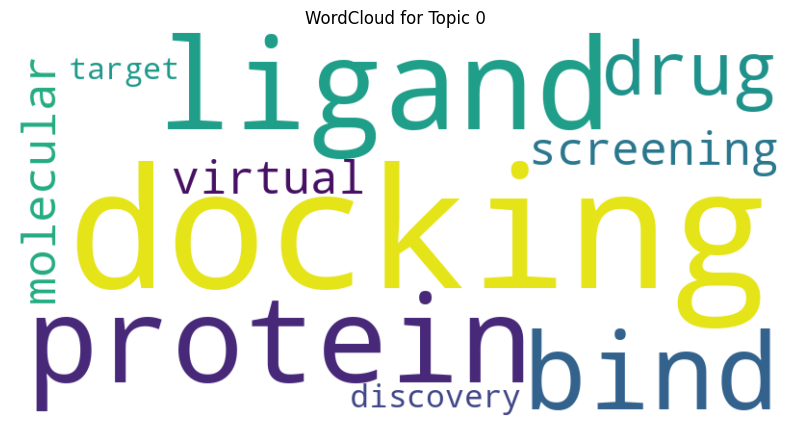

In [15]:
topic_id = 0  # choose a topic
words = dict(topic_model.get_topic(topic_id))

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(words)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"WordCloud for Topic {topic_id}")
plt.show()

In [20]:
def plot_topic_wordcloud(topic_model, topic_id, max_words=30):
    topic_words = dict(topic_model.get_topic(topic_id))

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=max_words,
        colormap="viridis"
    ).generate_from_frequencies(topic_words)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_id}", fontsize=14)
    plt.show()

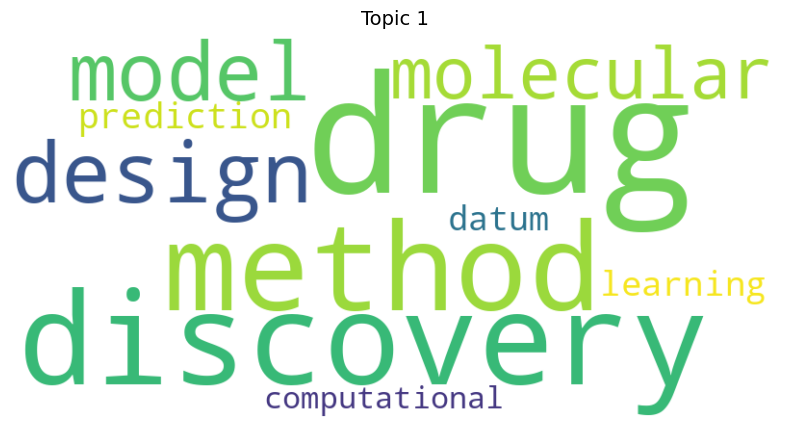

In [19]:
plot_topic_wordcloud(topic_model, topic_id=1, max_words=30)

In [22]:
# Get topic info table
topic_info = topic_model.get_topic_info()

# Remove noise topic (-1) and select top 6 by size
top_topics = (
    topic_info[topic_info.Topic != -1]
    .sort_values("Count", ascending=False)
    .head(6)["Topic"]
    .tolist()
)

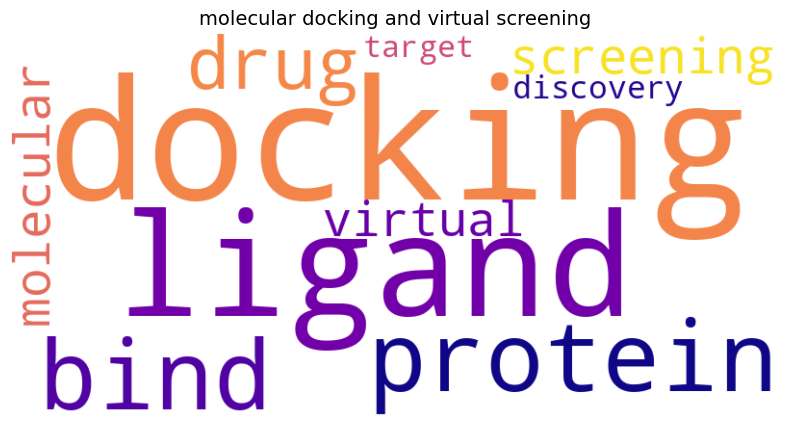

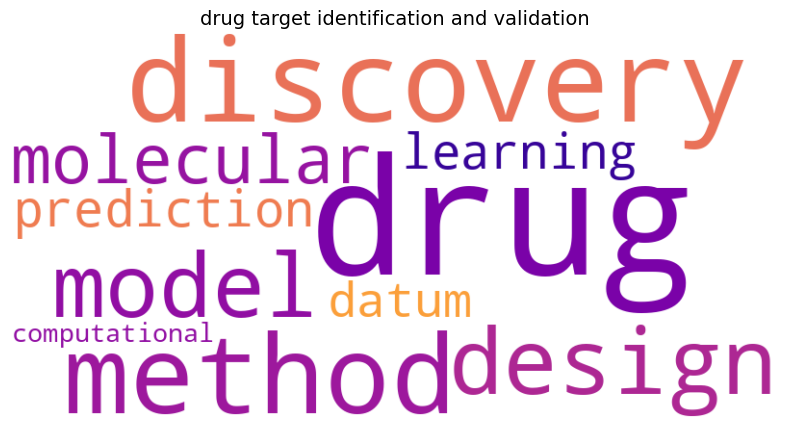

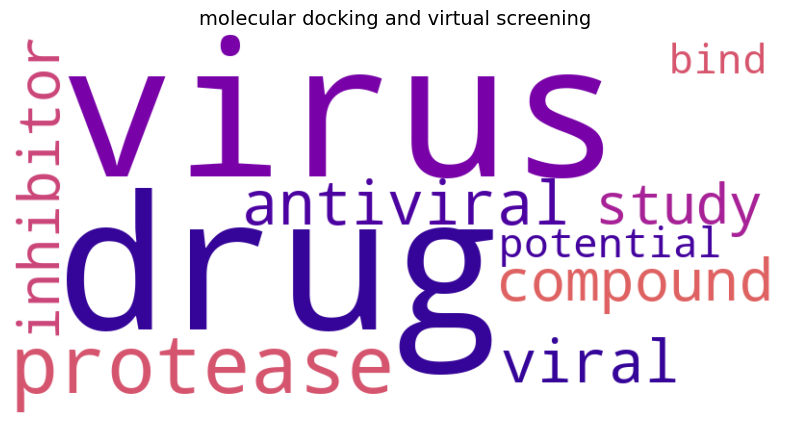

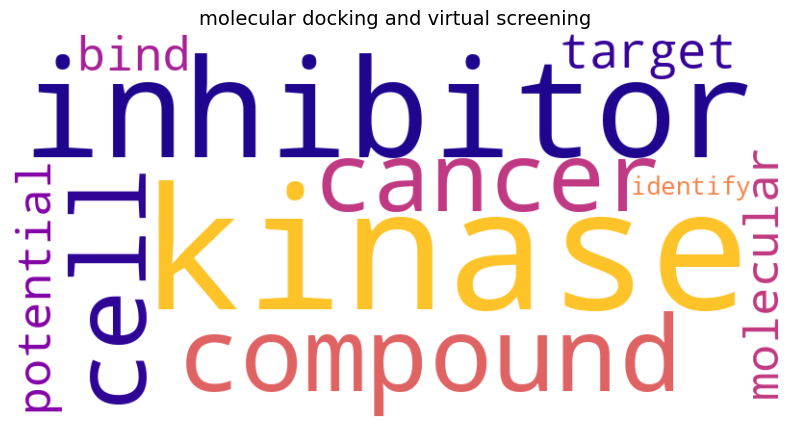

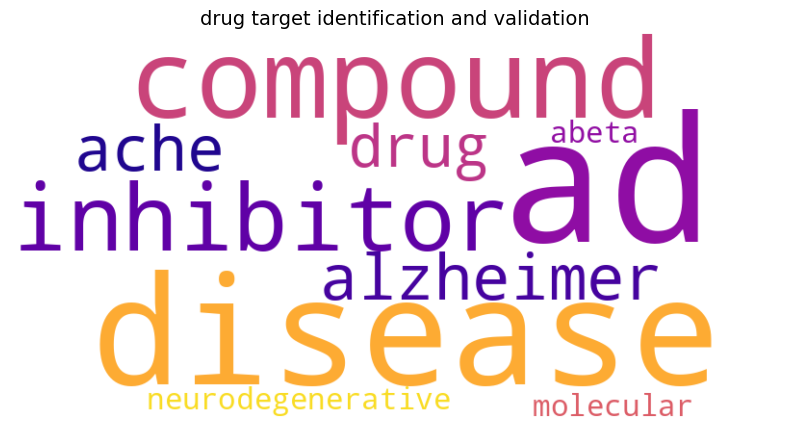

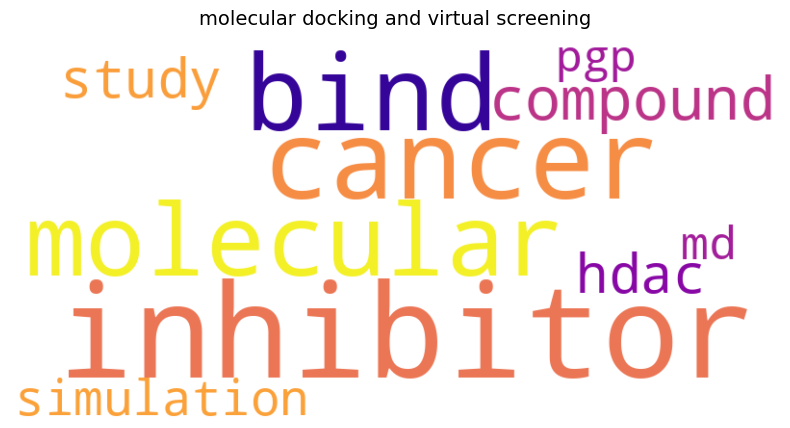

In [23]:
for t in top_topics:
    label = zero_shot_labels.get(t, f"Topic {t}")
    topic_words = dict(topic_model.get_topic(t))

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=30,
        colormap="plasma"
    ).generate_from_frequencies(topic_words)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(label, fontsize=14)
    plt.show()